# Flujo y transporte conservativo de la especie $c_1 = SO_4^{2-}$ — versión revisada

Versión revisada del notebook `01_C1_flow_tran` (RTWMA). Resuelve con **MODFLOW 6 + FloPy** el flujo estacionario (GWF) y el transporte conservativo (GWT) en una columna 1D de $L = 30$ m.

**Cambios respecto a la versión original**

| # | Cambio | Motivo |
|---|---|---|
| 1 | Paso de tiempo de transporte $\Delta t = 0.1$ d (`NSTP = 400`) y malla de 120 celdas | Con $\Delta t = 1$ d y $\Delta x = 1$ m la dispersión numérica era ≈ 39 % de la física (Euler implícito aporta $v^2\Delta t/2 = 0.08$ m²/d) |
| 2 | Pulso inicial definido **por posición** ($11 < x < 12$ m), no por índice | Permite refinar la malla sin cambiar el problema |
| 3 | Se elimina el paquete `CNC` en la celda 1 | Era redundante con `WEL` + `SSM` (el pozo aportaba 0 de masa) |
| 4 | `ModflowGwtdis` (no `ModflowGwfdis`) y `length_units` | Clase correcta para GWT; las unidades se pasaban pero no se usaban |
| 5 | Ruta **relativa** en `FMI` | Portabilidad |
| 6 | Caudal del pozo con espesor `top - botm`; dispersión efectiva calculada | Evita errores si `botm ≠ 0`; $D_{xx}=0.2$ m²/d se deriva, no se declara |
| 7 | Verificaciones: carga vs. solución analítica, balance de masa, concentración vs. solución analítica | El original no validaba nada |
| 8 | Lectura de resultados con `get_alldata()` y gráficas sin LaTeX externo | Menos código y sin dependencias |
| 9 | Anexo con estudio de convergencia en $\Delta t$ y $\Delta x$ | Cuantifica el error numérico |

## 1. Planteamiento

**Flujo** (1D, confinado, estacionario):
$$0 = \frac{\partial}{\partial x}\left(K_x \frac{\partial h}{\partial x}\right) + q_s,\qquad
\left.\frac{\partial h}{\partial x}\right|_{x=0}=0,\qquad h(L)=1.0\ \text{m}$$

**Transporte** (advección + dispersión, conservativo):
$$\frac{\partial (\theta c_1)}{\partial t} = -\frac{\partial (q_x c_1)}{\partial x} + \frac{\partial}{\partial x}\left(\theta D_{xx} \frac{\partial c_1}{\partial x}\right) + q_s c_s,\qquad D_{xx} = \alpha_L |v_x| + D^*$$

con $v_x = q_x/\theta$. Condición inicial: $c_1 = 1.0000329$ en todo el dominio salvo en $11 < x < 12$ m, donde $c_1 = 200$.
El agua inyectada en $x = 0$ entra con $c_s = 1.0000329$ y el soluto sale por $x = L$ advectivamente (gradiente dispersivo nulo).

**Notación.** $q_x$ = descarga específica (m/d); $q_s$ = fuente por unidad de volumen (d⁻¹). En MODFLOW 6 el pozo (`WEL`) se especifica como caudal $Q = q_s\,V_{celda}$ (m³/d).

## 2. Bibliotecas y ejecutable de MODFLOW 6

In [1]:
import os, re, shutil
import numpy as np
import matplotlib.pyplot as plt
import flopy

# Ejecutable: variable de entorno MF6EXE, o 'mf6' en el PATH
MF6_EXE = os.environ.get("MF6EXE") or shutil.which("mf6") or "/Users/luiggi/GitSites/00_NEAT/RTWMA/bin/macosarm/mf6"
print("FloPy :", flopy.__version__)
print("mf6   :", MF6_EXE)

# Gráficas: mathtext (no requiere instalar LaTeX); se aplica solo localmente en este notebook
plt.rcParams.update({"mathtext.fontset": "cm", "font.family": "serif", "figure.dpi": 110})

FloPy : 3.11.0
mf6   : /Users/luiggi/GitSites/00_NEAT/RTWMA/bin/macosarm/mf6


## 3. Datos del problema

Todos los parámetros se definen una sola vez. Los valores derivados ($v_x$, $D_{xx}$, $Q$, números adimensionales) se **calculan** en lugar de declararse.

In [2]:
# ---------------- Espacio ----------------
L     = 30.0        # longitud del dominio (m)
nlay, nrow = 1, 1
ncol  = 30         # 120 número de celdas (el original usaba 30)
delc  = 1.0         # ancho (m)
top, botm = 1.0, 0.0
thick = top - botm  # espesor (m)

# ---------------- Tiempo ----------------
t_total   = 40.0    # d
nstp_flow = 1       # flujo estacionario: un solo paso
nstp_tran = 40     # 40 transporte: dt = 0.1 d (el original usaba 40 pasos de 1 d)

# ---------------- Parámetros físicos ----------------
K        = 1.0           # conductividad hidráulica (m/d)
qx       = 0.2           # descarga específica (m/d)
theta    = 0.5           # porosidad
alh      = 0.5           # dispersividad longitudinal (m)
h_out    = 1.0           # carga fija en x = L (m)
c_bg     = 1.0000329     # concentración de fondo = concentración del agua inyectada
c_pulse  = 200.0         # concentración del pulso inicial
x_pulse  = (11.0, 12.0)  # posición del pulso (m)

# ---------------- Cantidades derivadas ----------------
delr   = L / ncol
Q_well = qx * delc * thick            # caudal del pozo (m3/d)
v      = qx / theta                   # velocidad de poro (m/d)
D_eff  = alh * v                      # dispersión efectiva (m2/d) -> 0.2
dt     = t_total / nstp_tran

print(f"Q pozo = {Q_well:.3f} m3/d | v = {v:.3f} m/d | D_eff = {D_eff:.3f} m2/d")
print(f"dx = {delr:.4f} m | dt = {dt:.4f} d")
print(f"Courant = v dt/dx = {v*dt/delr:.3f} | Peclet de malla = dx/alh = {delr/alh:.3f}")
print(f"Dispersión numérica por Euler implícito ≈ v² dt/2 = {v**2*dt/2:.4f} m2/d "
      f"({100*v**2*dt/2/D_eff:.1f} % de D_eff)")

# ---------------- Directorios ----------------
flow_ws = "io_mf6/c1_rev/gwf"
tran_ws = "io_mf6/c1_rev/gwt"

Q pozo = 0.200 m3/d | v = 0.400 m/d | D_eff = 0.200 m2/d
dx = 1.0000 m | dt = 1.0000 d
Courant = v dt/dx = 0.400 | Peclet de malla = dx/alh = 2.000
Dispersión numérica por Euler implícito ≈ v² dt/2 = 0.0800 m2/d (40.0 % de D_eff)


## 4. Funciones de construcción

Se encapsulan en funciones para poder reutilizarlas en el estudio de convergencia (sección 9). Cada paquete está comentado.

In [3]:
def build_flow(ws, ncol):
    "Construye la simulación de flujo GWF (estacionario)."
    delr = L / ncol
    sim = flopy.mf6.MFSimulation(sim_name="flow", sim_ws=ws, exe_name=MF6_EXE)
    flopy.mf6.ModflowTdis(sim, time_units="days", nper=1,
                          perioddata=[(t_total, nstp_flow, 1.0)])   # (PERLEN, NSTP, TSMULT)
    flopy.mf6.ModflowIms(sim)                                        # solver por defecto (CG, sistema simétrico)
    gwf = flopy.mf6.ModflowGwf(sim, modelname="flow", save_flows=True)

    # DIS: malla estructurada
    flopy.mf6.ModflowGwfdis(gwf, length_units="METERS", nlay=nlay, nrow=nrow, ncol=ncol,
                            delr=delr, delc=delc, top=top, botm=botm)
    # NPF: propiedades de flujo. icelltype=0 -> celda confinada (espesor constante).
    # save_specific_discharge: guarda q (DATA-SPDIS). save_saturation: requerido por GWT.
    flopy.mf6.ModflowGwfnpf(gwf, k=K, icelltype=0,
                            save_specific_discharge=True, save_saturation=True)
    # IC: carga inicial
    flopy.mf6.ModflowGwfic(gwf, strt=h_out)
    # STO: régimen permanente explícito (no requiere Ss)
    flopy.mf6.ModflowGwfsto(gwf, steady_state={0: True})
    # CHD: carga fija h = 1.0 m en x = L (última celda)
    flopy.mf6.ModflowGwfchd(gwf, stress_period_data=[[(0, 0, ncol - 1), h_out]], pname="CHD-1")
    # WEL: pozo de inyección en x = 0 (primera celda), con concentración auxiliar para GWT
    flopy.mf6.ModflowGwfwel(gwf, stress_period_data=[[(0, 0, 0), Q_well, c_bg]],
                            auxiliary=["CONCENTRATION"], pname="WEL-1")
    # x = 0 sin paquete de frontera -> flujo nulo por defecto
    # OC: salidas
    flopy.mf6.ModflowGwfoc(gwf, head_filerecord="flow.hds", budget_filerecord="flow.bud",
                           saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")])
    return sim, gwf


def build_transport(ws, ncol, nstp, flow_ws):
    "Construye la simulación de transporte GWT que lee el flujo ya calculado."
    delr = L / ncol
    xc = (np.arange(ncol) + 0.5) * delr
    sim = flopy.mf6.MFSimulation(sim_name="transport", sim_ws=ws, exe_name=MF6_EXE)
    flopy.mf6.ModflowTdis(sim, time_units="days", nper=1, perioddata=[(t_total, nstp, 1.0)])
    # IMS: BICGSTAB porque la advección hace la matriz asimétrica
    flopy.mf6.ModflowIms(sim, complexity="SIMPLE", linear_acceleration="BICGSTAB",
                         outer_dvclose=1e-8, inner_dvclose=1e-8)
    gwt = flopy.mf6.ModflowGwt(sim, modelname="transport", save_flows=True)

    # DIS (clase propia de GWT)
    flopy.mf6.ModflowGwtdis(gwt, length_units="METERS", nlay=nlay, nrow=nrow, ncol=ncol,
                            delr=delr, delc=delc, top=top, botm=botm)
    # IC: fondo + pulso definido por posición (independiente de la malla)
    c0 = np.full((nlay, nrow, ncol), c_bg)
    c0[0, 0, (xc > x_pulse[0]) & (xc < x_pulse[1])] = c_pulse
    flopy.mf6.ModflowGwtic(gwt, strt=c0)
    # ADV: advección con esquema TVD (2º orden, sin oscilaciones)
    flopy.mf6.ModflowGwtadv(gwt, scheme="TVD")
    # DSP: dispersión D = alh*|v|. MF6 exige ALH y ATH1 juntos (ATH1 no influye en 1D).
    # xt3d_off=True: formulación simple de diferencias finitas (suficiente en malla ortogonal 1D)
    flopy.mf6.ModflowGwtdsp(gwt, xt3d_off=True, alh=alh, ath1=alh)
    # MST: porosidad (almacenamiento de masa). Sin decaimiento ni sorción -> conservativo
    flopy.mf6.ModflowGwtmst(gwt, porosity=theta)
    # FMI: lee carga y flujos de la simulación GWF (ruta relativa al workspace de GWT)
    rel = os.path.relpath(flow_ws, ws)
    flopy.mf6.ModflowGwtfmi(gwt, packagedata=[("GWFHEAD",   f"{rel}/flow.hds", None),
                                              ("GWFBUDGET", f"{rel}/flow.bud", None)])
    # SSM: concentración con que entra el agua del pozo (auxiliar CONCENTRATION de WEL-1)
    # No se agrega CNC en x = 0: en una celda con CNC, MODFLOW ignora la fuente del pozo.
    flopy.mf6.ModflowGwtssm(gwt, sources=[("WEL-1", "AUX", "CONCENTRATION")])
    # x = L sin CNC: la masa sale con el flujo del CHD (advección) y el gradiente dispersivo es nulo
    # OC
    flopy.mf6.ModflowGwtoc(gwt, concentration_filerecord="transport.ucn",
                           budget_filerecord="transport.cbc",
                           saverecord=[("CONCENTRATION", "ALL"), ("BUDGET", "ALL")])
    return sim, gwt


def run(sim):
    sim.write_simulation(silent=True)
    ok, _ = sim.run_simulation(silent=True)
    assert ok, "La simulación no terminó correctamente; revisa mfsim.lst"


def max_discrepancy(lst_file):
    "Máxima |discrepancia porcentual| del balance (volumen o masa) en el archivo .lst."
    txt = open(lst_file).read()
    vals = [abs(float(m)) for m in re.findall(r"PERCENT DISCREPANCY\s*=\s*(-?[\d.]+)", txt)]
    return max(vals) if vals else np.nan

## 5. Flujo (GWF)

### 5.1 Construcción, escritura y ejecución

| Paquete | Función |
|---|---|
| `TDIS` | Un periodo de 40 d con un paso (flujo estacionario) |
| `IMS` | Solución del sistema lineal |
| `DIS` | Malla estructurada de 1 × 1 × `ncol` celdas |
| `NPF` | $K_x$, celdas confinadas; guarda descarga específica y saturación |
| `IC` | Carga inicial |
| `STO` | Régimen permanente (explícito) |
| `CHD` | $h = 1.0$ m en $x = L$ |
| `WEL` | Inyección de $Q = 0.2$ m³/d en $x=0$, con `CONCENTRATION` auxiliar |
| `OC` | Escribe `flow.hds` y `flow.bud` |

In [4]:
sim_gwf, gwf = build_flow(flow_ws, ncol)
run(sim_gwf)
print("Flujo terminado | discrepancia máx. del balance de volumen: "
      f"{max_discrepancy(os.path.join(flow_ws, 'flow.lst')):.4f} %")

Flujo terminado | discrepancia máx. del balance de volumen: 0.0000 %


### 5.2 Resultados y verificación contra la solución analítica

In [5]:
head = gwf.output.head().get_data()[0, 0, :]
spdis = gwf.output.budget().get_data(text="DATA-SPDIS")[0]
qx_num, qy_num, qz_num = flopy.utils.postprocessing.get_specific_discharge(spdis, gwf)
xc = gwf.modelgrid.xcellcenters[0]               # centros de celda (m)

# Solución analítica: qx = K dh/dx = cte  ->  h(x) = h_out + (qx/K)(x_chd - x)
# OJO: el CHD se impone en el CENTRO de la última celda (x_chd = L - dx/2), no en x = L.
x_chd   = xc[-1]
h_exact = h_out + (qx / K) * (x_chd - xc)
err_h = np.abs(head - h_exact).max()
print(f"max |h - h_analítica| = {err_h:.2e} m")
print(f"qx numérico: min = {qx_num.min():.6f}, max = {qx_num.max():.6f}  (esperado {qx})")
assert err_h < 1e-8 and np.allclose(qx_num, qx), "El flujo no coincide con la solución analítica"

max |h - h_analítica| = 1.78e-15 m
qx numérico: min = 0.200000, max = 0.200000  (esperado 0.2)


## 6. Transporte (GWT)

### 6.1 Construcción, escritura y ejecución

| Paquete | Función |
|---|---|
| `TDIS` | 40 d en `nstp_tran` pasos |
| `IMS` | `BICGSTAB` (matriz asimétrica por la advección) |
| `DIS` | Misma malla que GWF |
| `IC` | Fondo + pulso en $11 < x < 12$ m |
| `ADV` | Advección con TVD |
| `DSP` | Dispersión $D = \alpha_L \lvert v\rvert$ |
| `MST` | Porosidad |
| `FMI` | Lee `flow.hds` y `flow.bud` (el único paso de flujo se reutiliza en todos los pasos de transporte) |
| `SSM` | Concentración del agua inyectada por `WEL-1` |
| `OC` | Escribe `transport.ucn` y `transport.cbc` |

In [6]:
sim_gwt, gwt = build_transport(tran_ws, ncol, nstp_tran, flow_ws)
run(sim_gwt)
print("Transporte terminado | discrepancia máx. del balance de masa: "
      f"{max_discrepancy(os.path.join(tran_ws, 'transport.lst')):.4f} %")

Transporte terminado | discrepancia máx. del balance de masa: 0.0000 %


### 6.2 Lectura de resultados

In [7]:
o_conc  = gwt.output.concentration()
times_c = np.array(o_conc.get_times())          # (nstp,)
c_all   = o_conc.get_alldata()[:, 0, 0, :]      # (nstp, ncol): una sola lectura del archivo
c_end   = c_all[-1]
print(f"c_all: {c_all.shape} | pico a t = {times_c[-1]:.0f} d: {c_end.max():.3f} en x = {xc[c_end.argmax()]:.2f} m")

c_all: (40, 30) | pico a t = 40 d: 17.384 en x = 26.50 m


## 7. Verificaciones

### 7.1 Balance de masa
La masa en exceso del pulso ($c - c_{bg}$) debe repartirse entre la que permanece en el dominio y la que salió por $x = L$. Se calcula la masa que sigue en el dominio y se compara con la analítica (gaussiana en dominio infinito, que a $x>L$ es masa ya perdida).

In [8]:
from math import erf, sqrt
cell_vol = delr * delc * thick * theta                       # volumen de agua por celda (m3)
M0   = (c_pulse - c_bg) * (x_pulse[1] - x_pulse[0]) * delc * thick * theta   # masa en exceso inicial
Mdom = ((c_end - c_bg) * cell_vol).sum()                      # masa en exceso que queda
x0   = 0.5 * sum(x_pulse)
sig  = sqrt(2 * D_eff * t_total)
frac_in = 0.5 * (erf((L - (x0 + v*t_total)) / (sig * sqrt(2))) - erf((0 - (x0 + v*t_total)) / (sig * sqrt(2))))
print(f"Masa en exceso inicial  : {M0:8.3f}")
print(f"Masa en el dominio t=40 : {Mdom:8.3f}  ({100*Mdom/M0:.1f} %)")
print(f"Fracción esperada (gaussiana libre dentro de 0<x<L): {100*frac_in:.1f} %")

Masa en exceso inicial  :   99.500
Masa en el dominio t=40 :   71.225  (71.6 %)
Fracción esperada (gaussiana libre dentro de 0<x<L): 73.4 %


### 7.2 Comparación con la solución analítica
Para un pulso inicial que ocupa $x_0 \pm \Delta/2$ en un medio infinito, con velocidad $v$ y dispersión $D$:
$$c(x,t) = c_{bg} + \frac{M}{\sqrt{4\pi D t}}\exp\left[-\frac{(x - x_0 - vt)^2}{4Dt}\right],\qquad M = (c_{pulse}-c_{bg})\,\Delta$$
Es válida lejos de la frontera de salida, por lo que el error se mide en $x \le 27$ m.

In [9]:
def c_analitica(x, t, v=v, D=D_eff, x0=x0, cb=c_bg, M=(c_pulse - c_bg) * (x_pulse[1] - x_pulse[0])):
    return cb + M / np.sqrt(4*np.pi*D*t) * np.exp(-(x - x0 - v*t)**2 / (4*D*t))

mask = xc <= 27.0
ca_end = c_analitica(xc, t_total)
err_rel = np.abs(c_end[mask] - ca_end[mask]).sum() / np.abs(ca_end[mask] - c_bg).sum()
print(f"Pico numérico = {c_end.max():.3f} | pico analítico = {ca_end.max():.3f}")
print(f"Error relativo L1 (x ≤ 27 m) = {100*err_rel:.2f} %")

Pico numérico = 17.384 | pico analítico = 20.847
Error relativo L1 (x ≤ 27 m) = 18.49 %


## 8. Visualización

### 8.1 Flujo

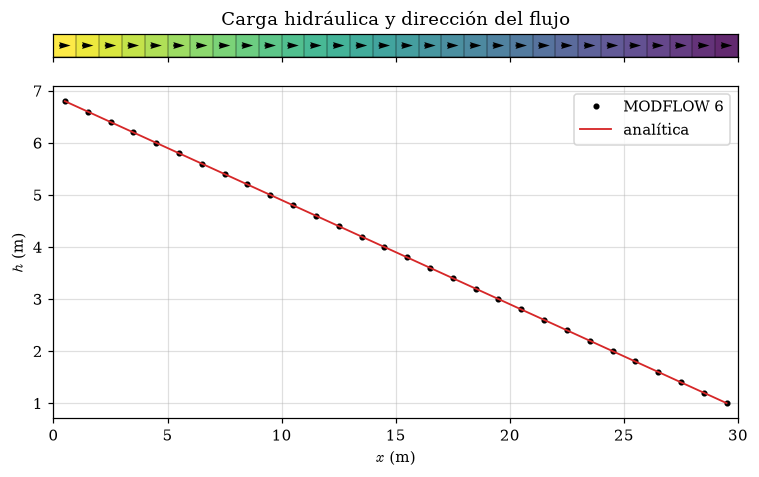

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(7, 4.5), height_ratios=[0.25, 1])
pmv = flopy.plot.PlotMapView(model=gwf, ax=ax1)
pmv.plot_grid(colors="k", lw=0.3)
pmv.plot_array(head, cmap="viridis", alpha=0.6)
ax1.set_yticks([]); ax1.set_aspect("equal")
ax1.set_title("Carga hidráulica y dirección del flujo")
step = max(ncol // 30, 1)
ax1.quiver(xc[::step], np.full_like(xc[::step], 0.5), qx_num[0, 0, ::step], 0*qx_num[0, 0, ::step],
           pivot="mid", scale=12, width=0.006)

ax2.plot(xc, head, "o", ms=3, c="k", label="MODFLOW 6")
ax2.plot(xc, h_exact, "-", c="C3", lw=1.2, label="analítica")
ax2.set_xlim(0, L); ax2.set_xlabel("$x$ (m)"); ax2.set_ylabel("$h$ (m)")
ax2.grid(alpha=0.4); ax2.legend()
plt.tight_layout(); plt.show()

### 8.2 Perfiles de concentración (numérico vs. analítico)

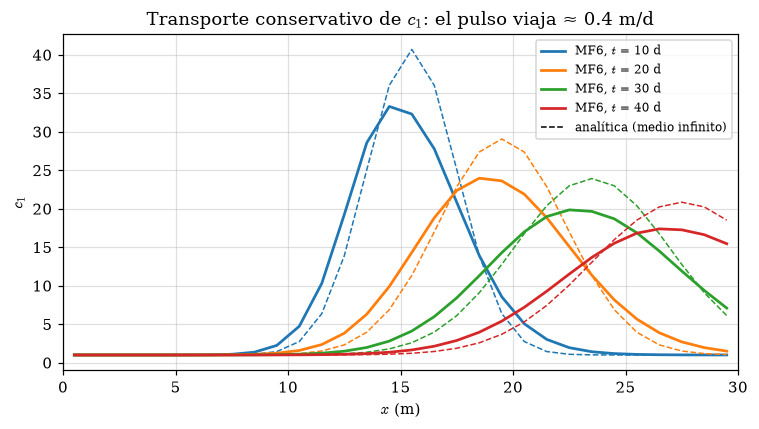

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
targets = [10, 20, 30, 40]
for i, tt in enumerate(targets):
    k = np.argmin(np.abs(times_c - tt))
    ax.plot(xc, c_all[k], "-", c=f"C{i}", lw=1.8, label=f"MF6, $t$ = {times_c[k]:.0f} d")
    ax.plot(xc, c_analitica(xc, times_c[k]), "--", c=f"C{i}", lw=1.0)
ax.plot([], [], "k--", lw=1.0, label="analítica (medio infinito)")
ax.set_xlim(0, L); ax.set_xlabel("$x$ (m)"); ax.set_ylabel("$c_1$")
ax.grid(alpha=0.4); ax.legend(fontsize=8)
ax.set_title("Transporte conservativo de $c_1$: el pulso viaja ≈ 0.4 m/d")
plt.tight_layout(); 
plt.savefig("40d.png")
plt.show()


### 8.3 Series de tiempo en puntos de observación

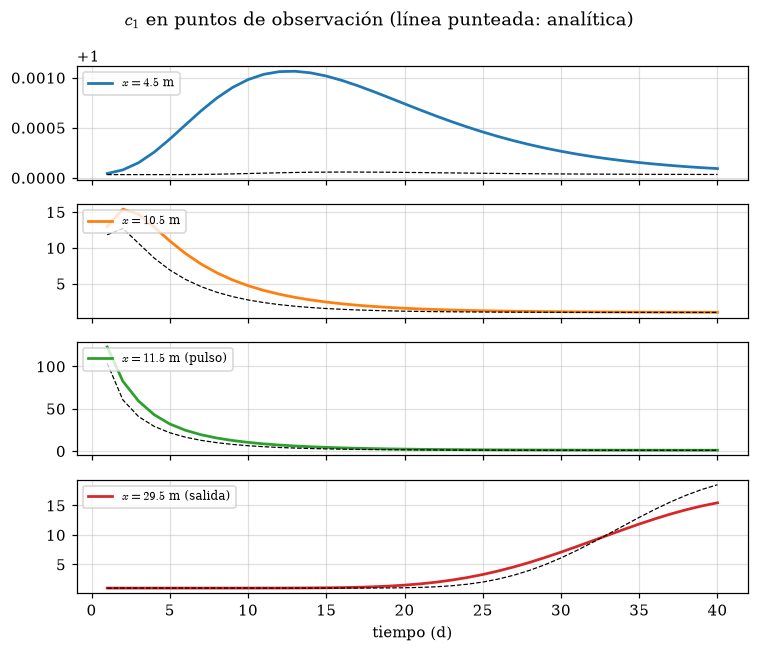

In [12]:
x_obs = {"$x = 4.5$ m": 4.5, "$x = 10.5$ m": 10.5, "$x = 11.5$ m (pulso)": 11.5, "$x = 29.5$ m (salida)": 29.5}
fig, axs = plt.subplots(len(x_obs), 1, sharex=True, figsize=(7, 6))
for ax, (lab, xo), col in zip(axs, x_obs.items(), ["C0", "C1", "C2", "C3"]):
    j = np.argmin(np.abs(xc - xo))
    ax.plot(times_c, c_all[:, j], c=col, lw=1.8, label=lab)
    ax.plot(times_c, c_analitica(xc[j], times_c), "k--", lw=0.8)
    ax.grid(alpha=0.4); ax.legend(loc="upper left", fontsize=8)
axs[-1].set_xlabel("tiempo (d)")
fig.suptitle("$c_1$ en puntos de observación (línea punteada: analítica)")
plt.tight_layout(); plt.show()

## 9. Anexo: convergencia en $\Delta t$ y $\Delta x$

Se repite la simulación completa (flujo + transporte) con distintas combinaciones y se mide el error contra la solución analítica. La primera fila es la configuración del notebook original (30 celdas, $\Delta t = 1$ d).

In [13]:
configs = [(30, 40), (30, 400), (60, 160), (120, 400), (120, 1600)]
rows = []
for nc, ns in configs:
    root = f"io_mf6/c1_rev/conv_{nc}_{ns}"
    s_f, g_f = build_flow(f"{root}/gwf", nc); run(s_f)
    s_t, g_t = build_transport(f"{root}/gwt", nc, ns, f"{root}/gwf"); run(s_t)
    x_n = g_t.modelgrid.xcellcenters[0]
    c_n = g_t.output.concentration().get_data()[0, 0, :]        # último tiempo (40 d)
    m = x_n <= 27.0
    ca = c_analitica(x_n, t_total)
    e  = np.abs(c_n[m] - ca[m]).sum() / np.abs(ca[m] - c_bg).sum()
    rows.append((nc, ns, t_total/ns, L/nc, c_n.max(), 100*e))

print(f"{'ncol':>5} {'NSTP':>6} {'dt (d)':>8} {'dx (m)':>7} {'pico':>8} {'error L1 (%)':>13}")
for r in rows:
    print(f"{r[0]:5d} {r[1]:6d} {r[2]:8.3f} {r[3]:7.3f} {r[4]:8.3f} {r[5]:13.2f}")
print(f"\nPico analítico (medio infinito): {c_analitica(x0 + v*t_total, t_total):.3f}")

 ncol   NSTP   dt (d)  dx (m)     pico  error L1 (%)
   30     40    1.000   1.000   17.384         18.49
   30    400    0.100   1.000   19.427          6.48
   60    160    0.250   0.500   19.778          4.82
  120    400    0.100   0.250   20.414          1.91
  120   1600    0.025   0.250   20.679          0.79

Pico analítico (medio infinito): 20.847


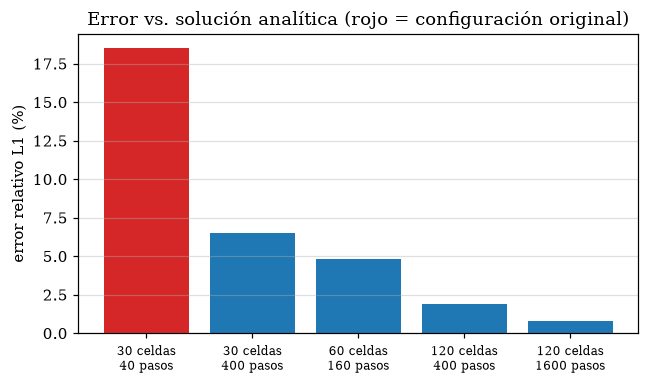

In [14]:
fig, ax = plt.subplots(figsize=(6, 3.6))
labels = [f"{r[0]} celdas\n{r[1]} pasos" for r in rows]
ax.bar(range(len(rows)), [r[5] for r in rows], color=["C3"] + ["C0"]*(len(rows)-1))
ax.set_xticks(range(len(rows))); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("error relativo L1 (%)"); ax.grid(axis="y", alpha=0.4)
ax.set_title("Error vs. solución analítica (rojo = configuración original)")
plt.tight_layout(); plt.show()

## 10. Notas y limitaciones

- **Dispersión numérica.** MODFLOW 6 integra el transporte con Euler implícito, que añade $\approx v^2 \Delta t/2$ de dispersión artificial. Para que la dispersión física ($D_{xx} = 0.2$ m²/d) domine, conviene $\Delta t \lesssim 0.1$ d y $\Delta x \lesssim 0.25$ m. Si se necesita comparar con otros códigos a $\Delta t = 1$ d, se puede subir `nstp_tran` y leer resultados cada $k$ pasos.
- **Posición de la carga fija.** En MODFLOW 6 el `CHD` fija la carga en el *centro* de la última celda ($x = L - \Delta x/2$), no en $x = L$. Por eso la carga analítica se referencia a ese punto.
- **Frontera de salida.** La solución analítica usada es de dominio infinito; cerca de $x = L$ es solo una referencia cualitativa.
- **Carga por encima del techo.** Con $K = 1$ y $q_x = 0.2$ la ley de Darcy exige $\Delta h = 6$ m, así que $h$ llega a 6.8 m con `top = 1.0`. Es válido para un acuífero confinado 1D (`icelltype = 0`); si se pasa a no confinado, habría que replantear el problema.
- **`ATH1`** es obligatorio junto con `ALH` en MF6 (6.7.0), aunque no influye en 1D.
- **Solver.** No bajar `rclose` por debajo de ~1e-8: valores como 1e-10 no son alcanzables y la simulación no converge.

## Referencias

- Langevin, C. D., Hughes, J. D., Provost, A. M., Russcher, M. J., & Panday, S. (2023). MODFLOW as a configurable Multi-Model Hydrologic Simulator. *Ground Water*. https://doi.org/10.1111/gwat.13351
- Original: https://luiggix.github.io/rtwma-doc/01_CT_gypsum_1D/01_C1_flow_tran.html